#### Notebook to read dataset provided by Knauer et al. 2022 and estimate model parameters

running the notebook in order will produce a modified data file in the folder "./derived/" if it doesn't already exist.

In [123]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import figure, set_axis_labels, use_style
from stillib_random import from_seed

from mscthesis.core.io import load_dataframe, save_dataframe

use_style()
mpl.rcParams['image.cmap'] = 'inferno'

df = load_dataframe("./raw/gm_dataset_Knauer_et_al_2022.csv")

# Data is a meta-dataset assembled by Knauer et al. (2022)
# DOI: https://doi.org/10.1111/nph.18363

# UNITS:
# Assimilation rate:    µmol/m^2/s
# Stomatal conductance: mol/m^2/s
# Porosity:             --
# Mesophyll thickness:  µm
# CO2 concentrations:   µmol/mol

# print number of unique species and plant functional types
print('Number of data points:', len(df))
print('Number of unique species:', df['species'].nunique())
print('Number of unique plant functional types:', df['plant_functional_type'].nunique())


Number of data points: 1883
Number of unique species: 617
Number of unique plant functional types: 13


MESOPHYLL THICKNESS


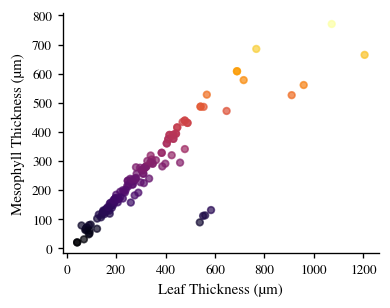

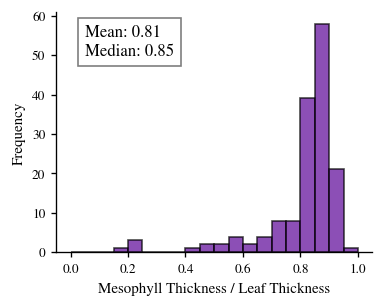

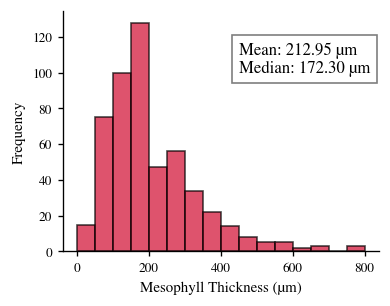

POROSITY


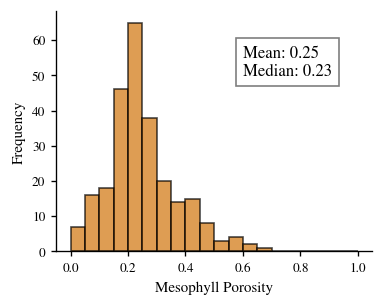

Number of data points: 218
Number of unique species: 113
Number of unique plant functional types: 9


In [124]:
df = load_dataframe("./raw/gm_dataset_Knauer_et_al_2022.csv")
df_ = df[["species", 
          "plant_functional_type", 
          "T_leaf", # leaf thickness µm
          "T_mesophyll", # mesophyll thickness µm
          "fias_mesophyll", # porosity --
          "An", # assimilation rate µmol/m^2/s
          "gs_CO2", # stomatal conductance mol/m^2/s
          "Ca_gas_exchange", # atmospheric CO2 µmol/mol
          "Ci", # IAS concentration µmol/mol
          "Cistar"]] # compensation point µmol/mol

# =======================================================
#  MESOPHYLL THICKNESS
# =======================================================

print("MESOPHYLL THICKNESS")

# filter out rows where EITHER leaf thickness OR mesophyll thickness is missing
df_ = df_.dropna(subset=["T_leaf", "T_mesophyll"], how="all")
# filter out rows where mesophyll thickness is larger than leaf thickness

# Make a scatter plot of leaf thickness vs mesophyll thickness
fig, ax = figure()
ax.scatter(df_["T_leaf"], df_["T_mesophyll"], c=df_["T_mesophyll"], alpha=0.7)
set_axis_labels(ax, "Leaf Thickness (µm)", "Mesophyll Thickness (µm)")
plt.show()

df_["T_ratio"] = df_["T_mesophyll"] / df_["T_leaf"]
t_ratio = df_["T_ratio"].dropna()
fig, ax = figure()
ax.hist(t_ratio, bins=np.arange(0, 1.05, 0.05).tolist(), color="#5C0497", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Mesophyll Thickness / Leaf Thickness", "Frequency")
# write the mean and median in the plot
mean = t_ratio.mean()
median = t_ratio.median()
ax.text(0.05, 50, f"Mean: {mean:.2f}\nMedian: {median:.2f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

# Define a new column "mesophyll_thickness", which is mesophyll thickness if available or median * leaf thickness if mesophyll thickness is missing
df_["mesophyll_thickness"] = df_.apply(lambda row: row["T_mesophyll"] if not pd.isna(row["T_mesophyll"]) else median * row["T_leaf"], axis=1)
df_ = df_.dropna(subset=["mesophyll_thickness"])

# plot final distribution of mesophyll thickness
fig, ax = figure()
ax.hist(df_["mesophyll_thickness"], bins=np.arange(0, 850, 50).tolist(), color="#D10A2F", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Mesophyll Thickness (µm)", "Frequency")
# write the mean and median in the plot
mean = df_["mesophyll_thickness"].mean()
median = df_["mesophyll_thickness"].median()
ax.text(450, 100, f"Mean: {mean:.2f} µm\nMedian: {median:.2f} µm", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

# =======================================================
#  POROSITY
# =======================================================

print("POROSITY")

df_ = df_.dropna(subset=["fias_mesophyll"])
# plot distribution of porosity
fig, ax = figure()
ax.hist(df["fias_mesophyll"].dropna(), bins=np.arange(0, 1.05, 0.05).tolist(), color="#D1740A", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Mesophyll Porosity", "Frequency")
# write the mean and median in the plot
mean = df["fias_mesophyll"].mean()
median = df["fias_mesophyll"].median()
ax.text(0.60, 50, f"Mean: {mean:.2f}\nMedian: {median:.2f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

print('Number of data points:', len(df_))
print('Number of unique species:', df_['species'].nunique())
print('Number of unique plant functional types:', df_['plant_functional_type'].nunique())


ATMOSPHERIC CO2 CONCENTRATION


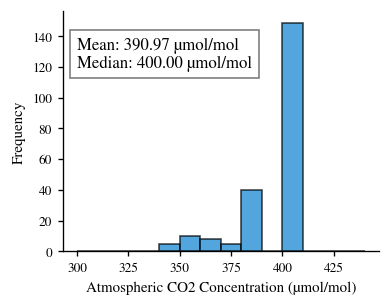

ASSIMILATION RATE


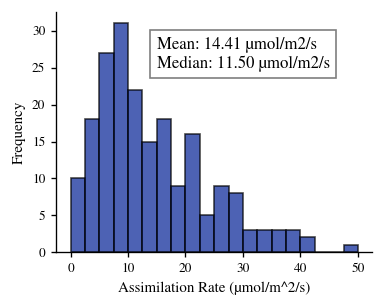

SUBSTOMATAL CO2 CONCENTRATION


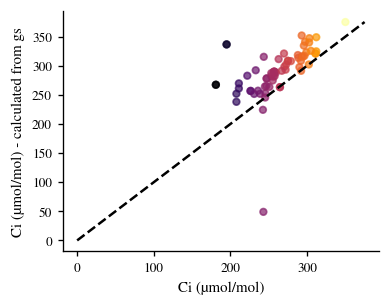

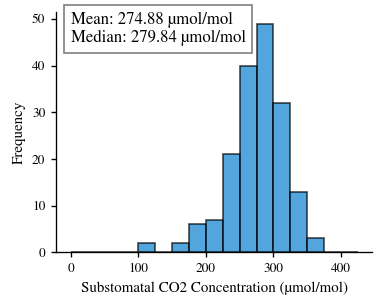

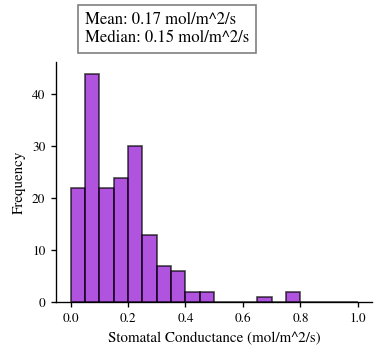

CO2 COMPENSATION POINT


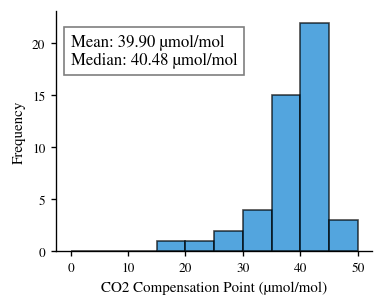

Number of data points: 175
Number of unique species: 88
Number of unique plant functional types: 8


In [125]:
print("ATMOSPHERIC CO2 CONCENTRATION")

# assign median to df_ where Ca_gas_exchange is missing
median = df["Ca_gas_exchange"].median()
df_["Ca_gas_exchange"] = df_["Ca_gas_exchange"].fillna(median)
# plot distribution of atmospheric CO2 concentration
fig, ax = figure()
ax.hist(df_["Ca_gas_exchange"], bins=np.arange(300, 450, 10).tolist(), color="#0A7FD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Atmospheric CO2 Concentration (µmol/mol)", "Frequency")
# write the mean and median in the plot
mean = df_["Ca_gas_exchange"].mean()
median = df_["Ca_gas_exchange"].median()
ax.text(300, 120, f"Mean: {mean:.2f} µmol/mol\nMedian: {median:.2f} µmol/mol", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

print("ASSIMILATION RATE")
df_ = df_.dropna(subset=["An"])
# plot distribution of assimilation rate
fig, ax = figure()
ax.hist(df_["An"], bins=np.arange(0, 52.5, 2.5).tolist(), color="#011F95", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Assimilation Rate (µmol/m^2/s)", "Frequency")
# write the mean and median in the plot
mean = df_["An"].mean()
median = df_["An"].median()
ax.text(15, 25, f"Mean: {mean:.2f} µmol/m2/s\nMedian: {median:.2f} µmol/m2/s", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

print("SUBSTOMATAL CO2 CONCENTRATION")
df_conc = df_.copy() 
df_conc["Ci_gs"] = df_conc["Ca_gas_exchange"] - df_conc["An"] / df_conc["gs_CO2"]
df_conc["gs_Ci"] = df_conc["An"] / (df_conc["Ca_gas_exchange"] - df_conc["Ci"])

# scatter plot of Ci_gs vs Ci
fig, ax = figure()
ax.scatter(df_conc["Ci"], df_conc["Ci_gs"], c=df_conc["Ci"], alpha=0.7)
max_ = max(df_conc["Ci"].max(), df_conc["Ci_gs"].max())
ax.plot([0, max_], [0, max_], color="black", linestyle="--")
set_axis_labels(ax, "Ci (µmol/mol)", "Ci (µmol/mol) - calculated from gs")
plt.show()

df_["Ci"] = df_["Ci"].fillna(df_conc["Ci_gs"])
df_["gs_CO2"] = df_["gs_CO2"].fillna(df_conc["gs_Ci"])
df_ = df_.dropna(subset=["Ci", "gs_CO2"])

# plot distribution of Ci
fig, ax = figure()
ax.hist(df_["Ci"], bins=np.arange(0, 450, 25).tolist(), color="#0A7FD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Substomatal CO2 Concentration (µmol/mol)", "Frequency")
# write the mean and median in the plot
mean = df_["Ci"].mean()
median = df_["Ci"].median()
ax.text(0, 45, f"Mean: {mean:.2f} µmol/mol\nMedian: {median:.2f} µmol/mol", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

# plot distribution of gs_CO2
fig, ax = figure()
ax.hist(df_["gs_CO2"], bins=np.arange(0, 1.05, 0.05).tolist(), color="#8F0AD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "Stomatal Conductance (mol/m^2/s)", "Frequency")
# write the mean and median in the plot
mean = df_["gs_CO2"].mean()
median = df_["gs_CO2"].median()
ax.text(0.05, 50, f"Mean: {mean:.2f} mol/m^2/s\nMedian: {median:.2f} mol/m^2/s", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

print("CO2 COMPENSATION POINT")

# plot distribution of Cistar
fig, ax = figure()
ax.hist(df["Cistar"].dropna(), bins=np.arange(0, 55, 5).tolist(), color="#0A7FD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, "CO2 Compensation Point (µmol/mol)", "Frequency")
# write the mean and median in the plot
mean = df["Cistar"].mean()
median = df["Cistar"].median()
ax.text(0, 18, f"Mean: {mean:.2f} µmol/mol\nMedian: {median:.2f} µmol/mol", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

df_["Cistar"] = df_["Cistar"].fillna(df["Cistar"].median())

print('Number of data points:', len(df_))
print('Number of unique species:', df_['species'].nunique())
print('Number of unique plant functional types:', df_['plant_functional_type'].nunique())


In [126]:
# Filter dataframe and save to csv 
df_filtered = df_[["species", "plant_functional_type", "mesophyll_thickness", "fias_mesophyll", "An", "Ca_gas_exchange", "Ci", "Cistar", "gs_CO2"]]

# rename for convenience
df_filtered = df_filtered.rename(columns={
    "species": "species",
    "plant_functional_type": "PFT",
    "mesophyll_thickness": "L",
    "fias_mesophyll": "porosity",
    "An": "An",
    "Ca_gas_exchange": "Ca",
    "Ci": "Ci",
    "Cistar": "Cistar",
    "gs_CO2": "gs"
})

save_dataframe("./derived/Knauer_filtered.csv", df_filtered)

## ESTIMATION OF MODEL PARAMETERS

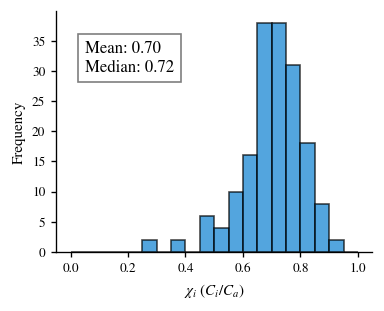

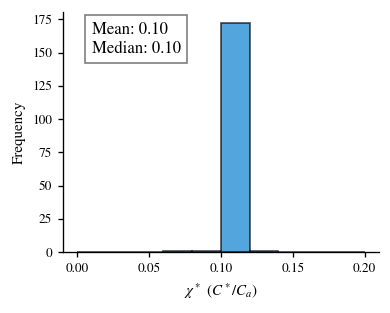

,Unnamed: 0,L,porosity,An,Ca,Ci,Cistar,gs,chii,compensation,r_inlet
count,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000,1750.000000
mean,995.737143,240.183407,0.245097,14.959657,391.588571,274.881822,40.472029,0.170128,0.702757,0.103534,3.000000
std,535.387336,174.048494,0.110030,9.324830,15.407998,42.542295,1.017716,0.128676,0.109210,0.005278,1.915402
min,0.000000,20.600000,0.060000,1.940000,346.000000,105.714286,29.900000,0.007000,0.264286,0.074750,0.000000
25%,631.000000,113.300000,0.176000,7.600000,380.000000,250.000000,40.485000,0.072000,0.660000,0.101212,1.333333
50%,1058.000000,190.300000,0.226000,11.900000,400.000000,279.839357,40.485000,0.150000,0.723077,0.101212,3.000000
75%,1437.000000,319.000000,0.300000,21.200000,400.000000,302.057143,40.485000,0.235000,0.763684,0.106539,4.666667
max,1881.000000,809.000000,0.600000,41.470000,450.000000,367.771261,48.800000,0.795000,0.933776,0.132609,6.000000


In [ ]:
# assume Ci to correspond to after r_inlet
# assume a range of r_inlet values
# calculate range of Ci_model values - treat as repeated measures
# calculate gamma, phi, r_pipe, chi_i, compensation, alpha
diffusivity = 1.51e-5 # m^2/s, diffusivity of CO2 in air at 25°C
tortuosity = 1.57 # from Niinemets and Reichstein (2003)

df_model = load_dataframe("./derived/Knauer_filtered.csv")
df_model["chii"] = df_model["Ci"] / df_model["Ca"]
df_model["compensation"] = df_model["Cistar"] / df_model["Ca"]
# for each row, assign a measurement_ID: #XXX where XXX is a unique 3 character string
df_model["measurement_ID"] = df_model.apply(lambda row: f"{row.name:03d}", axis=1)
ids = df_model["measurement_ID"].tolist()

# plot distributions of chii and compensation
fig, ax = figure()
ax.hist(df_model["chii"], bins=np.arange(0, 1.05, 0.05).tolist(), color="#0A7FD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, r"$\chi_i$ ($C_i$/$C_a$)", "Frequency")
# write the mean and median in the plot
mean = df_model["chii"].mean()
median = df_model["chii"].median()
ax.text(0.05, 30, f"Mean: {mean:.2f}\nMedian: {median:.2f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()  

fig, ax = figure()
ax.hist(df_model["compensation"], bins=np.arange(0, 0.22, 0.02).tolist(), color="#0A7FD1", edgecolor="black", alpha=0.7)
set_axis_labels(ax, r"$\chi^*$ ($C^*$/$C_a$)", "Frequency")
# write the mean and median in the plot
mean = df_model["compensation"].mean()
median = df_model["compensation"].median()
ax.text(0.01, 150, f"Mean: {mean:.2f}\nMedian: {median:.2f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()


r_inlet_values = np.linspace(0.0, 6.0, 10)

# assign a new column "r_inlet"
df_model["r_inlet"] = np.nan 
# for each measurement ID, insert a row for each r_inlet value, with the same values for all other columns except r_inlet
for _, row in df_model.iterrows():
    for r_inlet in r_inlet_values:
        new_row = row.copy()
        new_row["r_inlet"] = r_inlet
        df_model.loc[df_model.index.max() + 1] = new_row
df_model.dropna(subset=["r_inlet"], inplace=True)


